<a href="https://www.kaggle.com/code/lukaspanos/car-price-prediction-lin-reg-rf?scriptVersionId=344990311" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import pylab 
import scipy.stats as stats 
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge, Lasso


In [2]:
df = pd.read_csv("/kaggle/input/datasets/lukaspanos/cardetails/cardetails.csv")

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [5]:
#We must first drop irrelevant/leaky columns 
df = df.drop(columns=['Model'])

In [6]:
df.isnull().sum()

Make                    0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

In [7]:
#Since the data set is large and replacing the missing values with medians doesn't make sense, we will remove all the rows with missing values. 

df = df.dropna()


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1874 entries, 0 to 2057
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1874 non-null   object 
 1   Price               1874 non-null   int64  
 2   Year                1874 non-null   int64  
 3   Kilometer           1874 non-null   int64  
 4   Fuel Type           1874 non-null   object 
 5   Transmission        1874 non-null   object 
 6   Location            1874 non-null   object 
 7   Color               1874 non-null   object 
 8   Owner               1874 non-null   object 
 9   Seller Type         1874 non-null   object 
 10  Engine              1874 non-null   object 
 11  Max Power           1874 non-null   object 
 12  Max Torque          1874 non-null   object 
 13  Drivetrain          1874 non-null   object 
 14  Length              1874 non-null   float64
 15  Width               1874 non-null   float64
 16  Height     

In [9]:
#First, remove CC from the engine column
df['Engine'] = df['Engine'].str.replace(' cc', '', regex=False).astype(int)

In [10]:
print(df['Max Power'].unique())

['87 bhp @ 6000 rpm' '74 bhp @ 4000 rpm' '79 bhp @ 6000 rpm'
 '82 bhp @ 6000 rpm' '148 bhp @ 3400 rpm' '91 bhp @ 6000 rpm'
 '188 bhp @ 4000 rpm' '177 bhp @ 5100 rpm' '84 bhp @ 3750 rpm'
 '67 bhp @ 5500 rpm' '103 bhp @ 6000 rpm' '138 bhp @ 3750 rpm'
 '103 bhp @ 5000 rpm' '67 bhp @ 6000 rpm' '47 bhp @ 6000 rpm'
 '122 bhp @ 6400 rpm' '68 bhp @ 5500 rpm' '118 bhp @ 6000 rpm'
 '58 bhp @ 6000 rpm' '85 bhp @ 6000 rpm' '89 bhp @ 6000 rpm'
 '126 bhp @ 4000 rpm' '124 bhp @ 6000 rpm' '62 bhp @ 5500 rpm'
 '84 bhp @ 6000 rpm' '69 bhp @ 4000 rpm' '168 bhp @ 3000 rpm'
 '203 bhp @ 4200 rpm' '138 bhp @ 6400 rpm' '177 bhp @ 4200 rpm' '165@5500'
 '105 bhp @ 3800 rpm' '83 bhp @ 6000 rpm' '89 bhp @ 4000 rpm'
 '169 bhp @ 3750 rpm' '101 bhp @ 3600 rpm' '190 bhp @ 4000 rpm'
 '171 bhp @ 3750 rpm' '120 bhp @ 4000 rpm' '181 bhp @ 5000 rpm'
 '117 bhp @ 6600 rpm' '74 bhp @ 4200 rpm' '73 bhp @ 6000 rpm'
 '184 bhp @ 4000 rpm' '174 bhp @ 3400 rpm' '130 bhp @ 6300 rpm'
 '99 bhp @ 4000 rpm' '141 bhp @ 3500 rpm' '68 bhp

In [11]:
#Now we must seperate max TRQ and max PWR into 4 seperate columns with each their own RPM and BHP

# Max Power:
df['power_bhp'] = df['Max Power'].str.extract(r'([\d.]+)\s*(?:bhp)?\s*@').astype(float)
df['power_rpm'] = df['Max Power'].str.extract(r'@\s*([\d.]+)').astype(float)

In [12]:
# Max Torque 
df['torque_nm'] = df['Max Torque'].str.extract(r'([\d.]+)\s*(?:Nm)?\s*@').astype(float)
df['torque_rpm'] = df['Max Torque'].str.extract(r'@\s*([\d.]+)').astype(float)

In [13]:
#Drop Max Torque and Max Power

df.drop(columns=['Max Power', 'Max Torque'], inplace=True)
df.dropna(subset=['power_rpm'], inplace=True)

In [14]:
df.head()

,Make,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,power_bhp,power_rpm,torque_nm,torque_rpm
0,Honda,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198,FWD,3990.0,1680.0,1505.0,5.0,35.0,87.0,6000.0,109.0000,4500.0
1,Maruti Suzuki,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248,FWD,3995.0,1695.0,1555.0,5.0,42.0,74.0,4000.0,190.0000,2000.0
2,Hyundai,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197,FWD,3585.0,1595.0,1550.0,5.0,35.0,79.0,6000.0,112.7619,4000.0
3,Toyota,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197,FWD,3995.0,1745.0,1510.0,5.0,37.0,82.0,6000.0,113.0000,4200.0
4,Toyota,1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393,RWD,4735.0,1830.0,1795.0,7.0,55.0,148.0,3400.0,343.0000,1400.0


In [15]:
df.drop(columns=['Make', 'Location', 'Color',], inplace=True)

In [16]:
#Turn all the text columns into numeric columns 
df = pd.get_dummies(df, drop_first=True)
print(df.shape)
print(df.dtypes.value_counts())
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

(1872, 27)
bool       14
float64     9
int64       4
Name: count, dtype: int64


In [17]:
# Power-to-torque ratio — captures engine character
df['power_to_torque'] = df['power_bhp'] / df['torque_nm']

# Engine efficiency — how much power per cc
df['power_per_cc'] = df['power_bhp'] / df['Engine']

In [18]:
df['Age'] = 2026 - df['Year']
df.drop(columns=['Year'], inplace=True)

In [19]:
df.head()

,Price,Kilometer,Engine,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,power_bhp,power_rpm,torque_nm,torque_rpm,Fuel Type_CNG + CNG,Fuel Type_Diesel,Fuel Type_Hybrid,Fuel Type_LPG,Fuel Type_Petrol,Fuel Type_Petrol + CNG,Transmission_Manual,Owner_Second,Owner_Third,Owner_UnRegistered Car,Seller Type_Corporate,Seller Type_Individual,Drivetrain_FWD,Drivetrain_RWD,power_to_torque,power_per_cc,Age
0,505000,87150,1198,3990.0,1680.0,1505.0,5.0,35.0,87.0,6000.0,109.0000,4500.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0.798165,0.072621,9
1,450000,75000,1248,3995.0,1695.0,1555.0,5.0,42.0,74.0,4000.0,190.0000,2000.0,0,1,0,0,0,0,1,1,0,0,0,1,1,0,0.389474,0.059295,12
2,220000,67000,1197,3585.0,1595.0,1550.0,5.0,35.0,79.0,6000.0,112.7619,4000.0,0,0,0,0,1,0,1,0,0,0,0,1,1,0,0.700591,0.065998,15
3,799000,37500,1197,3995.0,1745.0,1510.0,5.0,37.0,82.0,6000.0,113.0000,4200.0,0,0,0,0,1,0,1,0,0,0,0,1,1,0,0.725664,0.068505,7
4,1950000,69000,2393,4735.0,1830.0,1795.0,7.0,55.0,148.0,3400.0,343.0000,1400.0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0.431487,0.061847,8


In [20]:
#Finding which features are collrelated/should be used
corr = df.corr()['Price'].sort_values(ascending=False)
print(corr)

Price                     1.000000
power_bhp                 0.776987
torque_nm                 0.676819
Engine                    0.609628
Fuel Tank Capacity        0.586104
Width                     0.577137
Length                    0.568875
power_per_cc              0.556228
Drivetrain_RWD            0.276951
Fuel Type_Diesel          0.166625
Owner_UnRegistered Car    0.162440
Seller Type_Corporate     0.093527
Height                    0.092941
Fuel Type_Hybrid          0.089945
Owner_Third               0.044577
Fuel Type_Petrol + CNG   -0.010895
Fuel Type_CNG + CNG      -0.014001
Seating Capacity         -0.024934
Fuel Type_LPG            -0.028339
Owner_Second             -0.055190
Seller Type_Individual   -0.081908
Fuel Type_Petrol         -0.145591
Kilometer                -0.147267
power_to_torque          -0.165620
power_rpm                -0.211285
Age                      -0.309409
torque_rpm               -0.333332
Transmission_Manual      -0.476598
Drivetrain_FWD      

In [21]:
features = [
    # Positive predictors
    'power_bhp', 'torque_nm', 'Engine', 'power_per_cc',
    'Fuel Tank Capacity', 'Width', 'Length',
    'Age', 'Drivetrain_RWD',
    'Fuel Type_Diesel', 'Owner_UnRegistered Car',

    # Negative predictors
    'Fuel Type_Petrol', 'Kilometer', 'power_rpm',
    'power_to_torque', 'torque_rpm', 'Transmission_Manual', 'Drivetrain_FWD',
]

X = df[features]
y = df['Price']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [23]:
pr = LinearRegression()

In [24]:
pr.fit(X_train, y_train)

LinearRegression()

In [25]:
pr.coef_

array([ 5.91148161e+04,  3.87020853e+03, -3.23380467e+03, -8.76799117e+07,
        7.82435313e+03,  1.32209688e+03,  1.45788079e+01, -1.38743544e+05,
       -1.83226675e+05, -9.91290918e+05,  1.63925463e+06, -3.80636343e+05,
       -7.58597992e+00,  4.12316353e+00,  6.89020399e+05, -1.81393374e+02,
        8.96077371e+03, -3.09244311e+05])

In [26]:
cdf = pd.DataFrame(pr.coef_, X.columns,columns=['Coef'] )
print(cdf)

                                Coef
power_bhp               5.911482e+04
torque_nm               3.870209e+03
Engine                 -3.233805e+03
power_per_cc           -8.767991e+07
Fuel Tank Capacity      7.824353e+03
Width                   1.322097e+03
Length                  1.457881e+01
Age                    -1.387435e+05
Drivetrain_RWD         -1.832267e+05
Fuel Type_Diesel       -9.912909e+05
Owner_UnRegistered Car  1.639255e+06
Fuel Type_Petrol       -3.806363e+05
Kilometer              -7.585980e+00
power_rpm               4.123164e+00
power_to_torque         6.890204e+05
torque_rpm             -1.813934e+02
Transmission_Manual     8.960774e+03
Drivetrain_FWD         -3.092443e+05


In [27]:
predictions = pr.predict(X_test)
predictions

array([ 2.56621464e+05,  1.02825299e+06,  4.21450606e+06,  9.02714465e+05,
       -1.71969620e+04,  3.12861127e+05,  5.77687749e+05,  1.68159923e+06,
        5.24778691e+05,  3.38289842e+06,  2.96954241e+06,  1.22077499e+06,
        1.39011844e+06,  3.32931894e+06,  3.66643123e+06,  1.98172958e+06,
        1.96586921e+06,  1.76221509e+06,  1.25841691e+06,  8.86057214e+05,
       -2.32358249e+04,  6.19867249e+05,  6.12871997e+05,  1.12271974e+06,
        9.39215565e+05, -1.76753977e+05,  3.27996260e+05,  5.06116013e+04,
        9.80177937e+05,  3.62231810e+06,  1.42038282e+06,  5.69740480e+04,
       -1.85725637e+05, -6.08737928e+05,  6.69002699e+06,  1.40576992e+06,
        7.25450236e+05,  5.79707202e+05, -5.21098591e+05,  2.26426581e+06,
        5.69073738e+06, -1.43077355e+05,  5.39531687e+05,  9.19702630e+05,
       -5.98588781e+05,  1.30636290e+06,  6.72885156e+05, -5.36489113e+05,
        3.82485786e+05,  1.24567457e+06,  2.18274564e+05, -3.64728715e+05,
        2.26439179e+06,  

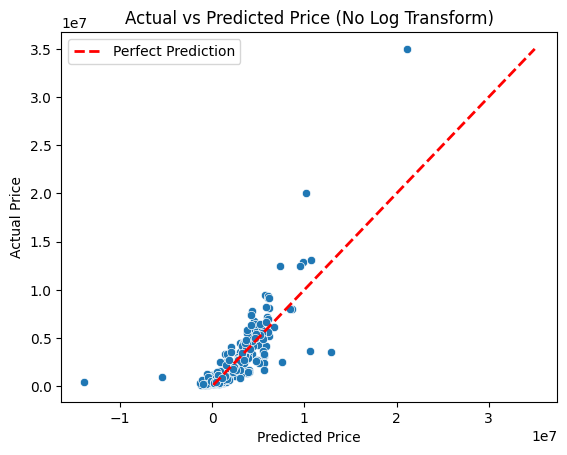

In [28]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel('Predicted Price')
plt.ylabel('Actual Price')
plt.title('Actual vs Predicted Price (No Log Transform)')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.legend()
plt.show()

In [29]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.2f}")

MAE:  702721.01
RMSE: 1420907.78
R²:   0.69


There is obviously a lot of room to improve here. Lets try to apply log transform in order to improve our results. 

In [30]:
y_log = np.log(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.3, random_state=42)

pr = LinearRegression()
pr.fit(X_train, y_train_log)

predictions_log = pr.predict(X_test)
predictions = np.exp(predictions_log)  # convert back to real prices
y_test_actual = np.exp(y_test_log)     # convert actuals back too

mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
r2 = r2_score(y_test_actual, predictions)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.2f}")

MAE:  349072.18
RMSE: 750165.70
R²:   0.91


The core problem was that price was skewed.

The dataset had most cars priced between ₹200K–₹800K, but a handful of luxury cars at ₹10M–₹35M. This is called a right-skewed distribution. Linear regression assumes the errors are normally distributed and consistent across the range — those luxury outliers violated both assumptions badly, which is why we were getting negative predictions for cheap cars.

np.log(price) compresses the scale. Instead of the model trying to predict values ranging from 200,000 to 35,000,000, it's now predicting values ranging from roughly 12 to 17 (since ln(200K) ≈ 12.2 and ln(35M) ≈ 17.4). That's a much more manageable range with a much more normal distribution.

It also changes what "error" means. Without the transform, being off by ₹500K on a ₹600K car and a ₹30M car is treated identically. With the log transform, the model is penalized proportionally — an error on a cheap car matters more than the same absolute error on an expensive car, which matches reality.

Our R² went from 0.69 → 0.91 because:

1. Negative predictions disappeared — log scale has no lower bound problem
2. The luxury outliers stopped pulling the regression line wildly
3. The relationship between features and log(price) is much closer to linear than features and raw price

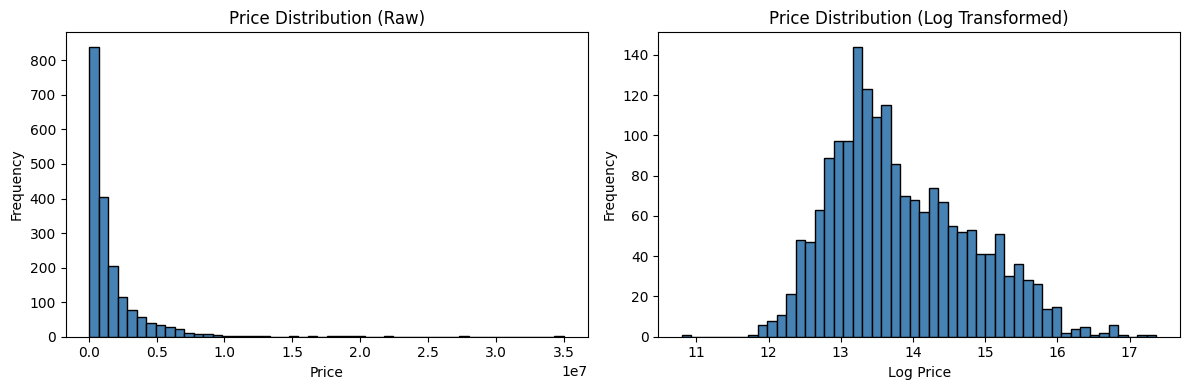

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw price distribution
axes[0].hist(y, bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# Log transformed distribution
axes[1].hist(np.log(y), bins=50, color='steelblue', edgecolor='black')
axes[1].set_title('Price Distribution (Log Transformed)')
axes[1].set_xlabel('Log Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

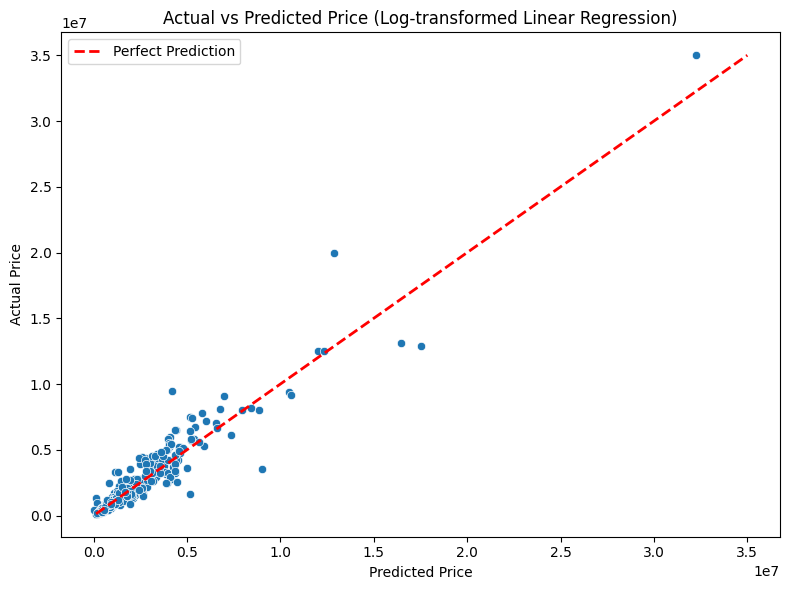

In [32]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=predictions, y=y_test_actual)
plt.xlabel('Predicted Price')
plt.ylabel('Actual Price')
plt.title('Actual vs Predicted Price (Log-transformed Linear Regression)')
plt.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.legend()
plt.tight_layout()
plt.show()


Now lets test out a random forest model and see if we can increase our R^2

In [33]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train_log)

rf_predictions_log = rf.predict(X_test)
rf_predictions = np.exp(rf_predictions_log)

mae = mean_absolute_error(y_test_actual, rf_predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, rf_predictions))
r2 = r2_score(y_test_actual, rf_predictions)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.2f}")

MAE:  287757.49
RMSE: 1198833.78
R²:   0.78


Why is Random Forest underperforming here?

Random Forest is predicting in log space but the variance in y_test_actual (real prices) is huge due to outliers. The R² calculation is being dragged down by a few very expensive cars the forest mispredicts badly.

But notice the MAE — ₹289K vs ₹349K for linear regression. So Random Forest is actually more accurate on average, it just handles the extreme outliers worse.

This is exactly why we need cross-validation and hyperparameter tuning now.

Instead of one train/test split, cross-validation splits your data into 5 folds and trains/tests 5 times, giving a much more reliable performance estimate:

In [34]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

cv_scores = cross_val_score(rf, X, np.log(y), cv=5, scoring='r2')

print(f"CV R² scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.2f}")
print(f"Std:     {cv_scores.std():.2f}")

CV R² scores: [0.95005723 0.94215679 0.93960912 0.9628423  0.94283677]
Mean R²: 0.95
Std:     0.01


Hyperparameter Tuning

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,  # uses all CPU cores
    verbose=1
)

grid_search.fit(X, np.log(y))

print("Best params:", grid_search.best_params_)
print("Best R²:    ", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best R²:     0.9471


MAE:  113773.37
RMSE: 633107.86
R²:   0.94


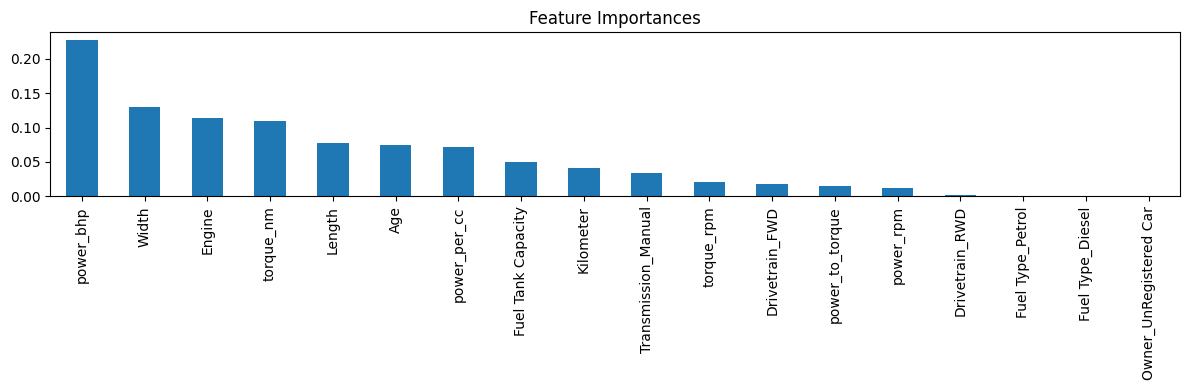

In [36]:
best_rf = grid_search.best_estimator_

rf_predictions_log = best_rf.predict(X_test)
rf_predictions = np.exp(rf_predictions_log)

mae = mean_absolute_error(y_test_actual, rf_predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, rf_predictions))
r2 = r2_score(y_test_actual, rf_predictions)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.2f}")

# Feature importance
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12, 4), title='Feature Importances')
plt.tight_layout()
plt.show()

In [37]:
from sklearn.linear_model import Ridge, Lasso

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train_log)
ridge_predictions = np.exp(ridge.predict(X_test))

r2_ridge = r2_score(y_test_actual, ridge_predictions)
mae_ridge = mean_absolute_error(y_test_actual, ridge_predictions)
print(f"Ridge — R²: {r2_ridge:.2f}, MAE: {mae_ridge:.2f}")

# Lasso
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train_log)
lasso_predictions = np.exp(lasso.predict(X_test))

r2_lasso = r2_score(y_test_actual, lasso_predictions)
mae_lasso = mean_absolute_error(y_test_actual, lasso_predictions)
print(f"Lasso — R²: {r2_lasso:.2f}, MAE: {mae_lasso:.2f}")

Ridge — R²: 0.90, MAE: 356318.82
Lasso — R²: 0.81, MAE: 534737.63


In [38]:
from sklearn.linear_model import RidgeCV, LassoCV

# RidgeCV tests multiple alphas automatically
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge_cv.fit(X_train, y_train_log)
print(f"Best Ridge alpha: {ridge_cv.alpha_}")

lasso_cv = LassoCV(alphas=[0.001, 0.01, 0.1, 1.0], cv=5)
lasso_cv.fit(X_train, y_train_log)
print(f"Best Lasso alpha: {lasso_cv.alpha_}")

Best Ridge alpha: 1.0
Best Lasso alpha: 0.001


In [39]:
lasso_coefs = pd.Series(lasso_cv.coef_, index=X.columns)
print("Features Lasso kept (non-zero):")
print(lasso_coefs[lasso_coefs != 0].sort_values(ascending=False))
print("\nFeatures Lasso removed:")
print(lasso_coefs[lasso_coefs == 0].index.tolist())

Features Lasso kept (non-zero):
Owner_UnRegistered Car    0.141308
power_bhp                 0.005838
Fuel Tank Capacity        0.003680
Width                     0.000705
torque_nm                 0.000346
Length                    0.000325
Kilometer                -0.000002
power_rpm                -0.000019
torque_rpm               -0.000027
Engine                   -0.000047
Drivetrain_RWD           -0.046804
Fuel Type_Diesel         -0.070009
Age                      -0.106189
Drivetrain_FWD           -0.134281
Fuel Type_Petrol         -0.135511
Transmission_Manual      -0.273759
dtype: float64

Features Lasso removed:
['power_per_cc', 'power_to_torque']
